# Music Recommendation System Using Machine Learning

When did we see a video on youtube let's say it was funny then the next time you open your youtube app you get recommendations of some funny videos in your feed ever thought about how? This is nothing but an application of Machine Learning using which recommender systems are built to provide personalized experience and increase customer engagement.

In this notebook, we will walk through the process of building a content-based music recommendation system using machine learning. The system recommends songs similar to a given input song based on metadata such as genre, artist name and track name. We will use the "TCC CEDs Music Dataset" which contains metadata about songs, including their genres, artists and lyrics.

## Step 1: Importing Libraries & Dataset
Python libraries make it very easy for us to handle the data and perform typical and complex tasks with a single line of code.

* Pandas- This library helps to load the data frame in a 2D array format and has multiple functions to perform analysis tasks in one go.
* Numpy - Numpy arrays are very fast and can perform large computations in a very short time.
* Matplotlib/Seaborn - This library is used to draw visualizations.
* Sklearn - This module contains multiple libraries having pre-implemented functions to perform tasks from data preprocessing to model development and evaluation.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

The dataset we are going to use contains data about songs released in the span of around 100 years. Along with some general information about songs some scientific measures of sound are also provided like loudness, acoustics, speechiness, and so on.

In [3]:
data = pd.read_csv('tcc_ceds_music.csv')  
data.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,romantic,1.0


## Step 2: Exploratory Data Analysis (EDA)
Before building the recommendation system, we perform exploratory data analysis (EDA) to gain insights into the dataset.

### Distribution of Songs by Genre
We visualize the top 10 genres in the dataset to understand the diversity of songs.

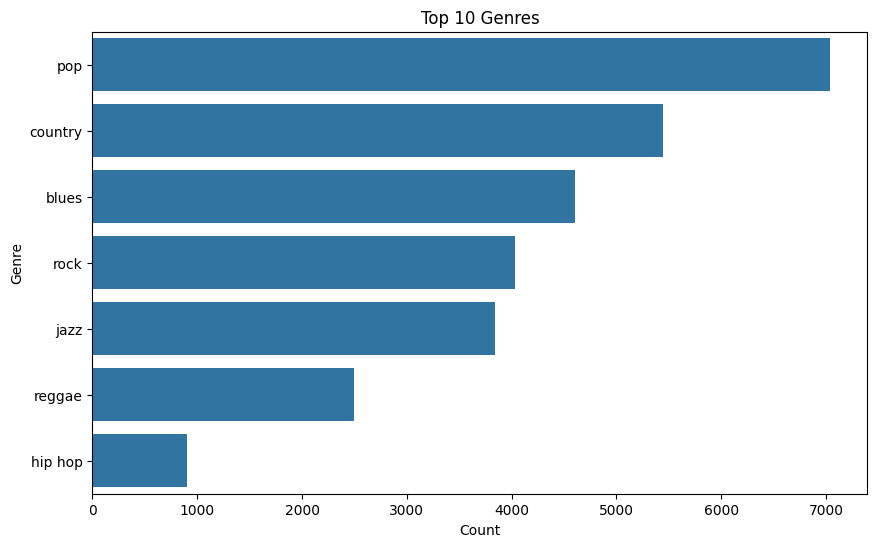

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(y='genre', data=data, order=data['genre'].value_counts().index[:10])
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

### Top Artists by Song Count
We identify the most popular artists based on the number of songs they have in the dataset.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22976\2127773168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')


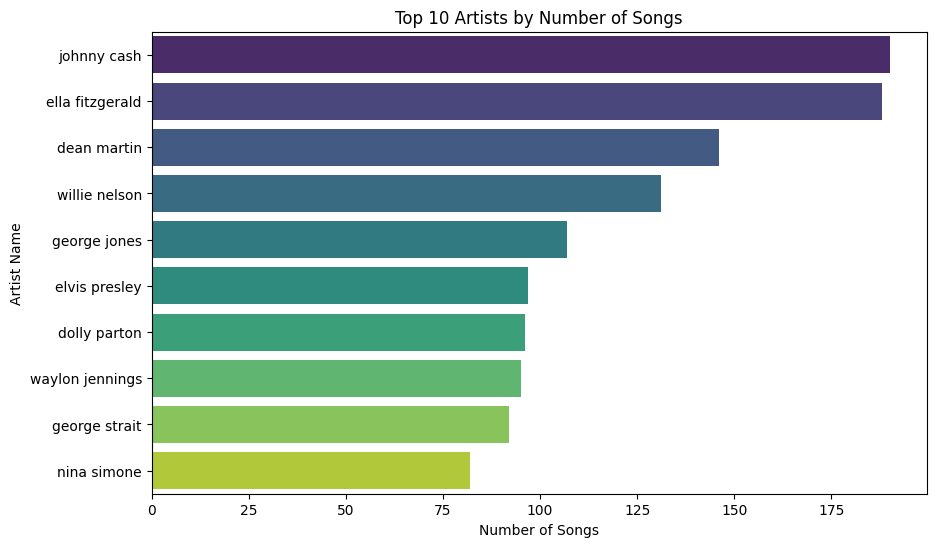

In [5]:
top_artists = data.groupby('artist_name').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')
plt.title('Top 10 Artists by Number of Songs')
plt.xlabel('Number of Songs')
plt.ylabel('Artist Name')
plt.show()

## Step 3: Preprocessing the Data
To build the recommendation system, we preprocess the data by combining relevant features and converting them into numerical vectors.

### Combine Features
We concatenate the genre, artist_name, and track_name columns into a single feature called combined_features.

In [6]:
data['combined_features'] = (
    data['genre'].fillna('') + ' ' +
    data['artist_name'].fillna('') + ' ' +
    data['track_name'].fillna('')
)

### Vectorize Text Data
We use TF-IDF Vectorization to convert the combined features into numerical vectors.

In [7]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(data['combined_features'])

### Compute Similarity Scores
We compute the cosine similarity between songs based on their vectorized features.

In [8]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def get_recommendations(song_title, data, cosine_sim, top_n=10):
    # Get the index of the song that matches the title
    idx = data[data['track_name'] == song_title].index
    if len(idx) == 0:
        print("Song not found in the dataset.")
        return
    
    idx = idx[0]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:top_n+1]  
    song_indices = [i[0] for i in sim_scores]

    recommendations = data.iloc[song_indices]
    return recommendations

### Explanation :

* The function retrieves the index of the input song.
* It computes similarity scores for all songs and sorts them in descending order.
* It returns the top-N most similar songs.

## Step 4: Generate Recommendations
We use the get_recommendations function to recommend songs similar to a specific input song (e.g., 'cry').

In [9]:
recommended_songs = get_recommendations('cry', data, cosine_sim, top_n=10)
print(recommended_songs[['track_name', 'artist_name', 'genre']])

                          track_name     artist_name  genre
56                         here am i     johnnie ray    pop
12887             keep on loving you  johnnie taylor  blues
15294              too many memories  johnnie taylor  blues
14542  there's nothing i wouldn't do  johnnie taylor  blues
14679                         lately  johnnie taylor  blues
13887                     steal away  johnnie taylor  blues
14701             don't make me late  johnnie taylor  blues
12881           baby, we've got love  johnnie taylor  blues
13247  i got to love somebody's baby  johnnie taylor  blues
12882            i need lots of love  johnnie taylor  blues


## Step 5: Visualize Recommendations
Finally, we visualize the recommended songs using a bar chart.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22976\269018342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='track_name', x='artist_name', data=recommended_songs, palette='coolwarm')


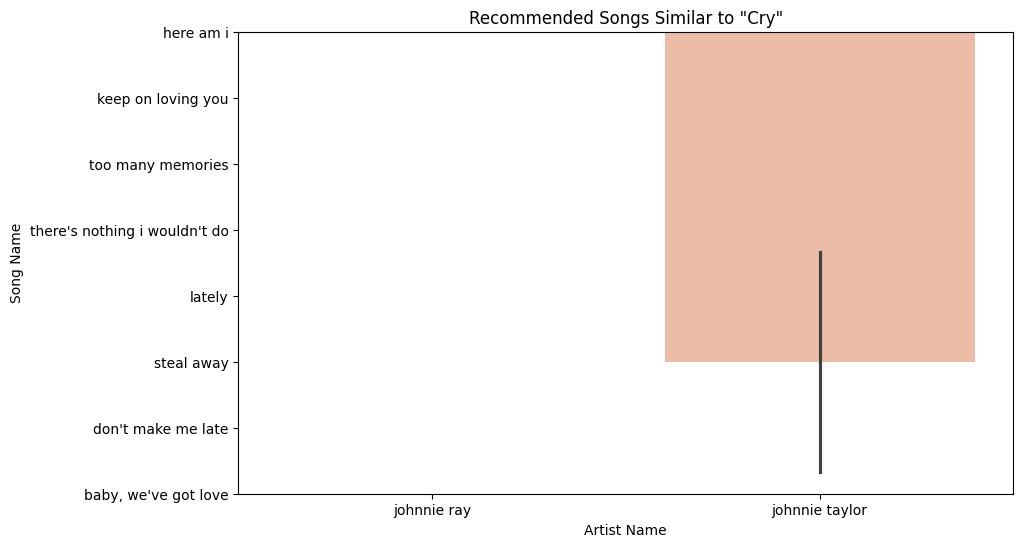

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(y='track_name', x='artist_name', data=recommended_songs, palette='coolwarm')
plt.title('Recommended Songs Similar to "Cry"')
plt.xlabel('Artist Name')
plt.ylabel('Song Name')
plt.show()

Although this model requires a lot of changes before it can be used in any real-world music app or website. But this is just an overview of how recommendation systems are built and used.